## **Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import time

## **Data Collection and Preparation**

Selecting the stocks and the time Horizon.

In [3]:
# Define stock universe
tickers = ["AAPL", "MSFT", "AMZN", "TSLA", "NVDA", "JPM"]

# Define date range
start_date = "2015-01-01"
end_date = "2025-01-01"

Downloading Raw Data for all the stocks.

In [4]:
all_data = {}

for ticker in tickers:
    print(f"Downloading data for {ticker}...")
    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            threads=False
        )[["Close"]]

        data.columns = [ticker]
        all_data[ticker] = data

        time.sleep(2)  # pause to reduce chance of rate limiting

    except Exception as e:
        print(f"Failed for {ticker}: {e}")

# Combine all stocks into one DataFrame
daily_prices = pd.concat(all_data.values(), axis=1)

# Preview data
daily_prices.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-02,24.214897,39.767689,15.4260,14.620667,0.482985,46.274311
2015-01-05,23.532721,39.401997,15.1095,14.006000,0.474828,44.837734
2015-01-06,23.534941,38.823677,14.7645,14.085333,0.460432,43.675121
2015-01-07,23.864946,39.316936,14.9210,14.063333,0.459232,43.741779
2015-01-08,24.781895,40.473576,15.0230,14.041333,0.476507,44.719250


In [6]:
import os

os.makedirs("data/processed", exist_ok=True)

daily_prices.to_csv("data/processed/daily_prices.csv")

Checking for missing values

In [7]:
# Basic checks
print("Shape of dataset:", daily_prices.shape)
print("\nMissing values by stock:")
print(daily_prices.isnull().sum())

Shape of dataset: (2516, 6)

Missing values by stock:
AAPL    0
MSFT    0
AMZN    0
TSLA    0
NVDA    0
JPM     0
dtype: int64


Converting daily prices to month end prices

In [9]:
# Convert daily prices to month-end prices
monthly_prices = daily_prices.resample("M").last()

# Display first 5 rows
monthly_prices.head()

/tmp/ipykernel_6907/1276049869.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = daily_prices.resample("M").last()


,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-31,25.949118,34.358738,17.726500,13.573333,0.460672,40.268803
2015-02-28,28.564177,37.558220,19.007999,13.556000,0.531330,45.378292
2015-03-31,27.668072,34.825932,18.605000,12.584667,0.504114,44.859947
2015-04-30,27.828173,41.660942,21.089001,15.070000,0.534702,47.155861
2015-05-31,29.089882,40.397194,21.461500,16.719999,0.535484,49.034340


In [10]:
# Remove rows where all values are missing
monthly_prices = monthly_prices.dropna(how="all")

# Forward fill any small missing values
monthly_prices = monthly_prices.ffill()

# Check again
print("Missing values after cleaning:")
print(monthly_prices.isnull().sum())

Missing values after cleaning:
AAPL    0
MSFT    0
AMZN    0
TSLA    0
NVDA    0
JPM     0
dtype: int64


In [11]:

# Save processed monthly price data
monthly_prices.to_csv("data/processed/monthly_prices.csv")

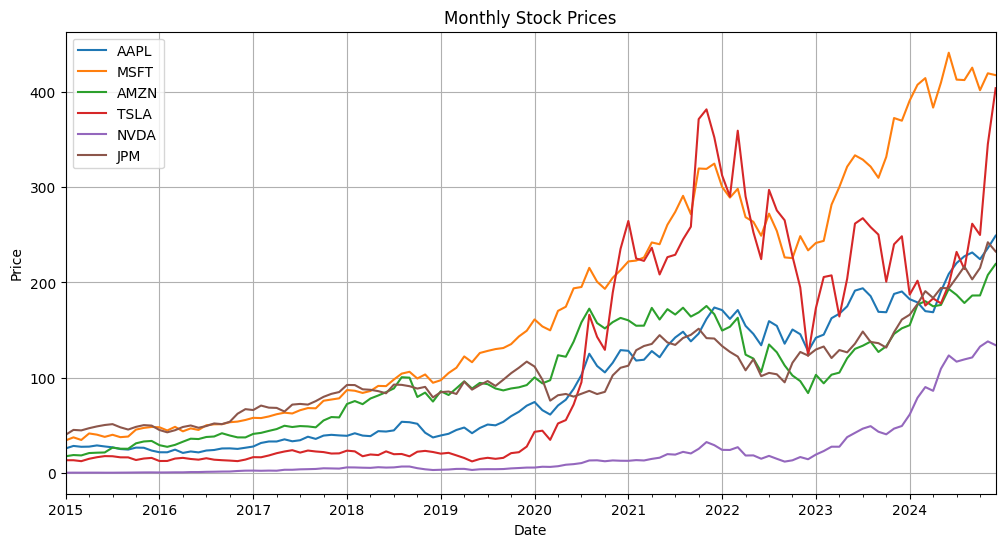

In [12]:
# Plot monthly prices
monthly_prices.plot(figsize=(12, 6))
plt.title("Monthly Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

## **Return Calculation**

***Step 3: Calculate Monthly Returns***

Calculate Monthly Returns

In [13]:
# Calculate monthly percentage returns
monthly_returns = monthly_prices.pct_change().dropna()

# Preview
monthly_returns.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-02-28,0.100776,0.093120,0.072293,-0.001277,0.153382,0.126885
2015-03-31,-0.031372,-0.072748,-0.021202,-0.071653,-0.051224,-0.011423
2015-04-30,0.005786,0.196262,0.133513,0.197489,0.060678,0.051180
2015-05-31,0.045339,-0.030334,0.017663,0.109489,0.001461,0.039836
2015-06-30,-0.037228,-0.057832,0.011323,0.069617,-0.091279,0.030101


In [14]:
print("Shape of monthly returns:", monthly_returns.shape)
print("\nMissing values:")
print(monthly_returns.isnull().sum())

Shape of monthly returns: (119, 6)

Missing values:
AAPL    0
MSFT    0
AMZN    0
TSLA    0
NVDA    0
JPM     0
dtype: int64


In [15]:
monthly_returns.to_csv("data/processed/monthly_returns.csv")

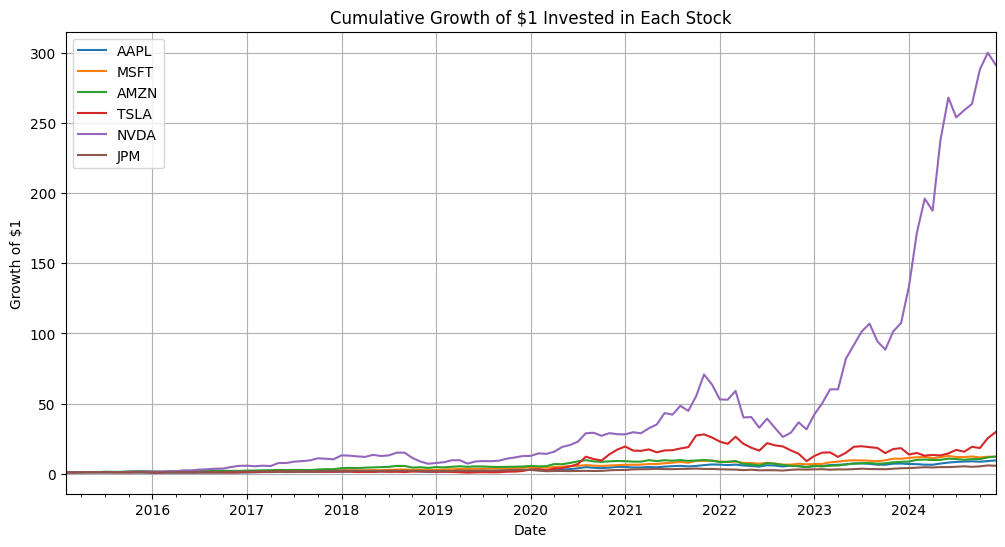

In [16]:
cumulative_stock_returns = (1 + monthly_returns).cumprod()

cumulative_stock_returns.plot(figsize=(12, 6))
plt.title("Cumulative Growth of $1 Invested in Each Stock")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

**Return Calculation**

Monthly stock returns were calculated using percentage change in month-end adjusted prices. Returns are the core input for portfolio construction because they measure how much each asset gained or lost over each period.

## **Equal-Weight Portfolio Construction**

In [17]:
# Number of stocks
n_assets = monthly_returns.shape[1]

# Equal weights
equal_weights = np.repeat(1 / n_assets, n_assets)

# Equal-weight portfolio monthly returns
equal_weight_returns = monthly_returns.dot(equal_weights)

# Convert to DataFrame for easier handling
equal_weight_portfolio = pd.DataFrame({
    "Equal_Weight_Returns": equal_weight_returns
})

equal_weight_portfolio.head()

,Equal_Weight_Returns
Date,
2015-02-28,0.090863
2015-03-31,-0.043270
2015-04-30,0.107485
2015-05-31,0.030576
2015-06-30,-0.012550


In [18]:
equal_weight_portfolio["Cumulative_Return"] = (1 + equal_weight_portfolio["Equal_Weight_Returns"]).cumprod()

equal_weight_portfolio.head()

,Equal_Weight_Returns,Cumulative_Return
Date,,
2015-02-28,0.090863,1.090863
2015-03-31,-0.043270,1.043661
2015-04-30,0.107485,1.155839
2015-05-31,0.030576,1.191179
2015-06-30,-0.012550,1.176231


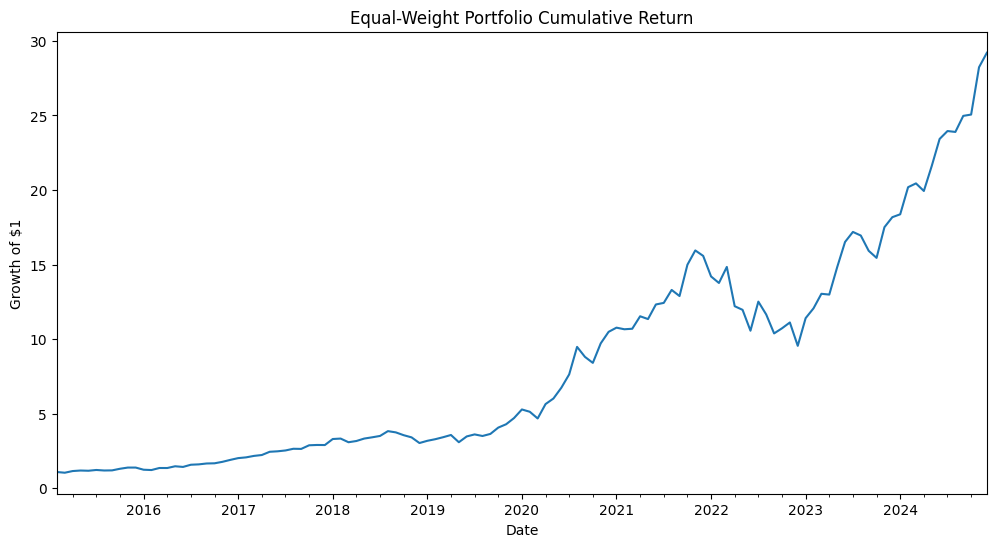

In [19]:
equal_weight_portfolio["Cumulative_Return"].plot(figsize=(12, 6))
plt.title("Equal-Weight Portfolio Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(False)
plt.show()

## **Momentum Strategy Implementation**

**Create momentum signal (past 3-month return)**

In [20]:
# Calculate 3-month momentum
momentum_signal = monthly_prices.pct_change(3)

momentum_signal.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-30,0.072413,0.212528,0.189688,0.110265,0.160702,0.171027
2015-05-31,0.018404,0.075589,0.129077,0.233402,0.007817,0.080568


**Rank stocks each month**

In [21]:
# Rank stocks based on momentum (higher = better)
ranks = momentum_signal.rank(axis=1, ascending=False)

ranks.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-30,6.0,1.0,2.0,5.0,4.0,3.0
2015-05-31,5.0,4.0,2.0,1.0,6.0,3.0


**Select top 3 stocks each month**

In [22]:
# Select top 3 stocks
top_n = 3

selection = ranks <= top_n
selection.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-31,False,False,False,False,False,False
2015-02-28,False,False,False,False,False,False
2015-03-31,False,False,False,False,False,False
2015-04-30,False,True,True,False,False,True
2015-05-31,False,False,True,True,False,True


**Create dynamic weights**

In [23]:
# Equal weight among selected stocks
strategy_weights = selection.div(selection.sum(axis=1), axis=0)

strategy_weights.head()

,AAPL,MSFT,AMZN,TSLA,NVDA,JPM
Date,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-30,0.0,0.333333,0.333333,0.000000,0.0,0.333333
2015-05-31,0.0,0.000000,0.333333,0.333333,0.0,0.333333


**Calculate strategy portfolio returns**

In [24]:
# Align weights and returns
strategy_returns = (strategy_weights.shift(1) * monthly_returns).sum(axis=1)

strategy_returns = strategy_returns.to_frame(name="Momentum_Returns")

strategy_returns.head()

,Momentum_Returns
Date,
2015-01-31,0.000000
2015-02-28,0.000000
2015-03-31,0.000000
2015-04-30,0.000000
2015-05-31,0.009055


**Cumulative returns**

In [25]:
strategy_returns["Cumulative_Return"] = (1 + strategy_returns["Momentum_Returns"]).cumprod()

strategy_returns.head()

,Momentum_Returns,Cumulative_Return
Date,,
2015-01-31,0.000000,1.000000
2015-02-28,0.000000,1.000000
2015-03-31,0.000000,1.000000
2015-04-30,0.000000,1.000000
2015-05-31,0.009055,1.009055


**Compare both portfolios**

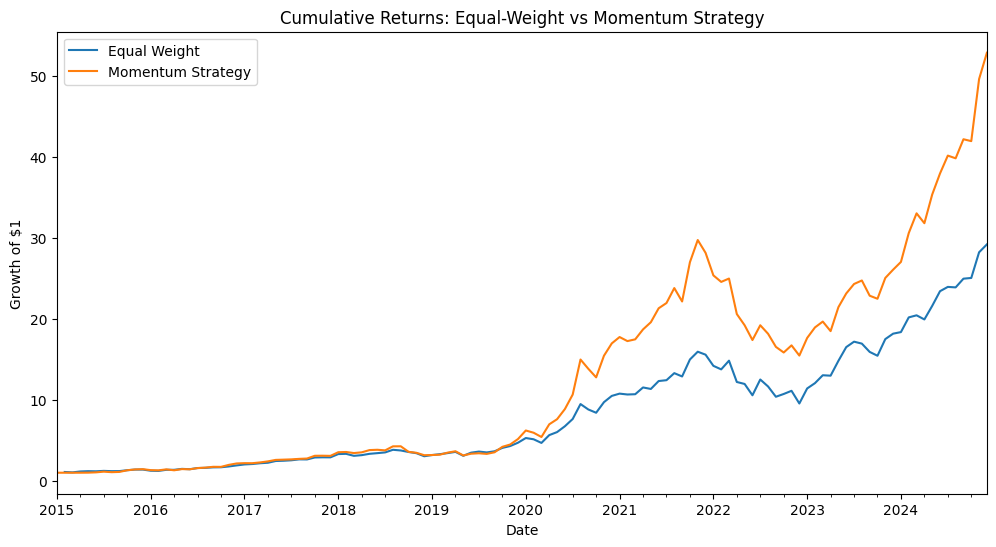

In [26]:
comparison = pd.concat([
    equal_weight_portfolio["Cumulative_Return"],
    strategy_returns["Cumulative_Return"]
], axis=1)

comparison.columns = ["Equal Weight", "Momentum Strategy"]

comparison.plot(figsize=(12, 6))
plt.title("Cumulative Returns: Equal-Weight vs Momentum Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(False)
plt.show()

## **Performance Evaluation**

**Define risk-free rate**

In [27]:
risk_free_rate = 0.02  # 2% annual

**Function to calculate metrics**

In [28]:
def calculate_performance_metrics(returns, rf_rate=0.02):

    # Annualised return
    annual_return = (1 + returns.mean())**12 - 1

    # Annualised volatility
    annual_volatility = returns.std() * np.sqrt(12)

    # Sharpe ratio
    sharpe_ratio = (annual_return - rf_rate) / annual_volatility

    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    return {
        "Annual Return": annual_return,
        "Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown
    }

**Calculating metrics for both portfolio**

In [29]:
# Equal-weight metrics
eq_metrics = calculate_performance_metrics(equal_weight_portfolio["Equal_Weight_Returns"])

# Momentum strategy metrics
mom_metrics = calculate_performance_metrics(strategy_returns["Momentum_Returns"])

In [30]:
metrics_df = pd.DataFrame([eq_metrics, mom_metrics],
                         index=["Equal Weight", "Momentum Strategy"])

metrics_df

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Equal Weight,0.450576,0.259301,1.660524,-0.401085
Momentum Strategy,0.554258,0.313288,1.705326,-0.479845


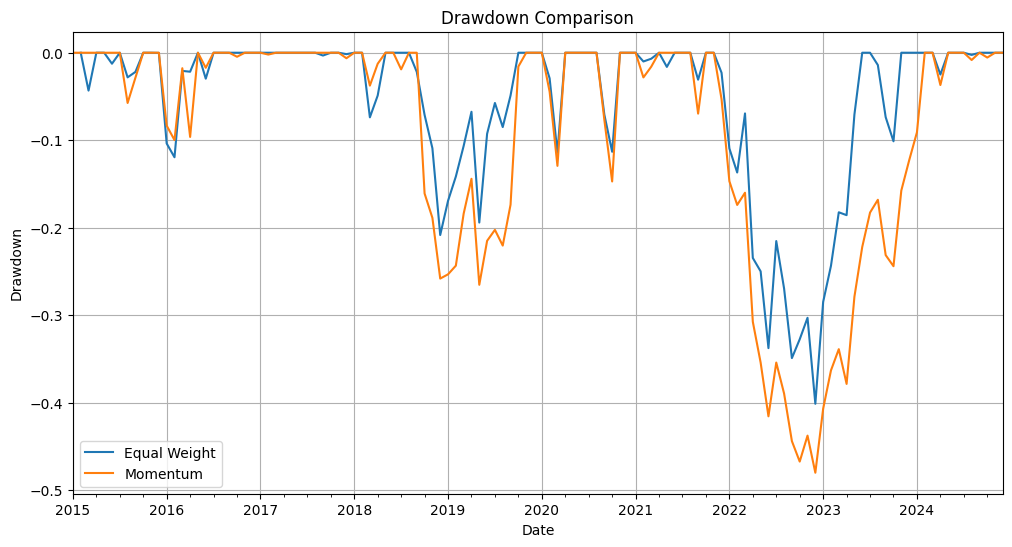

In [31]:
def compute_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown

eq_drawdown = compute_drawdown(equal_weight_portfolio["Equal_Weight_Returns"])
mom_drawdown = compute_drawdown(strategy_returns["Momentum_Returns"])

drawdown_df = pd.concat([eq_drawdown, mom_drawdown], axis=1)
drawdown_df.columns = ["Equal Weight", "Momentum"]

drawdown_df.plot(figsize=(12, 6))
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

**Drawdown Analysis**

The drawdown chart shows the percentage decline from each portfolio’s historical peak. The momentum strategy experiences deeper drawdowns compared to the equal-weight portfolio, particularly during periods of market reversal such as 2022–2023. While momentum delivers higher returns, it also exposes the portfolio to greater downside risk. In contrast, the equal-weight portfolio demonstrates relatively more stable performance with smaller drawdowns, highlighting a trade-off between return and risk.

## **Key Insights**

- The momentum strategy outperformed the equal-weight portfolio in terms of cumulative returns.
- However, it experienced higher volatility and deeper drawdowns, particularly during market reversals.
- This demonstrates the trade-off between return and risk in portfolio construction.
- Equal-weight provides more stable performance, while momentum offers higher return potential with higher risk.